In [ ]:
from langchain_core.messages import HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults 
from langgraph.types import Command 
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain.agents import create_agent 
from IPython.display import Image, display 
from dotenv import load_dotenv
from langchain_experimental.tools import PythonREPLTool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.types import interrupt, Command
from langchain_core.messages import AIMessage, HumanMessage
import json

from langgraph.graph import MessagesState
from typing import Annotated, Sequence, List, Literal, TypedDict 
from pydantic import BaseModel, Field 
from operator import add


load_dotenv()

llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite')

tavily_search = TavilySearchResults(max_results=2)

python_repl_tool = PythonREPLTool()

In [115]:
from operator import add


class Supervisor(BaseModel):
    next: Literal["interviewer","scenario-generator", "teacher","hint-generator", "question_explainer"] = Field(
        description="Determines which specialist to activate next in the workflow sequence: "
                    "'interviewer' when needed to evaluate,"
                    "'scenario-generator' when new scenarios need to be created or explored, "
                    "'teacher' when the user needs guidance or instruction,"
                    "'hint-generator' when user explicitly requests hints or assistance."
                    "'question_explainer' when user needs explanation on the latest question"
    )
    reason: str = Field(
        description="Detailebd justification for the routing decision, explaining the rationale behind selecting the particular specialist and how this advances the task toward completion."
    )

class query_evaluation(BaseModel):
    is_technical: bool = Field(
        description="AIMessage indicating whether the user's query is technical in nature, relevant to system design, SQL, API design, or any other technical topic."
    )

class Scenario(BaseModel):
    title: str = Field(description="Short title of the interview scenario")
    description: str = Field(
        description="Detailed description of the interview scenario"
    )
    difficulty: Literal["easy", "intermediate", "hard"]
    constraints: List = Field(
        description="Any constraints or limitations for the interview scenario"
    )
    concepts: List[str] = Field(
        description="Technical concepts and subtopics that the scenario is intended to assess."
    )
    
class InterviewSummary(BaseModel):
    overall_assessment: str  = Field(description="Overall summary and the reasoning for it")
    strengths: list[str]
    weaknesses: list[str]
    covered_topics: list[str]
    pending_topics: list[str]
    score: float = Field(
        description="""Score rubric
        9-10: Excellent answer
        7-8: Mostly correct with minor omissions
        5-6: Basic understanding
        3-4: Major misconceptions
        0-2: Incorrect
        deduct marks if its off topic or not relevant to latest question"""
    )
    next_question: str

class Teacher(BaseModel):
    explained_topics: list[str]
    explanation: str

class InterviewState(MessagesState):
    scenario: Scenario

    previous_questions: Annotated[list[str], add]
    current_question: str

    interview_summary: InterviewSummary
    avg_score: float

    question_number: int
    follow_up_count: int
    failure_count: int

    explained_topics: Annotated[list[str], add]

    assessment_history: Annotated[list[str], add]

    interview_stage: Literal[
        "scenario",
        "waiting_for_answer",
        "evaluating",
        "completed"
    ]




In [116]:
def supervisor_node(state: MessagesState) -> Command[Literal["interviewer","scenario-generator", "teacher", "hint-generator", "question_explainer"]]:

    system_prompt = ('''
                 
        You are a workflow supervisor managing a team of three specialized agents: Prompt Enhancer, Researcher, and Coder. Your role is to orchestrate the workflow by selecting the most appropriate next agent based on the current state and needs of the task. Provide a clear, concise rationale for each decision to ensure transparency in your decision-making process.

        **Team Members**:
        1. Scenario-Generator
        - Creates interview scenarios.
        - Generates new situations for the user.

        2. Teacher
        - Explains concepts.
        - Teaches system design, SQL, API design, etc.

        3. Interviewer
        - Reviews the user's answer.
        - Scores the answer.
        - Provided follow-up questions based on the user's answer.
        - Provides strengths and weaknesses.

        4. Question Explainer
        - Explains the latest interview question or a specific part of it.
        - Route to this node only when the user is asking for clarification about the interviewer's most recent question.
        - This includes explicit requests such as:
            - "Explain the last question."
            - "Can you explain that?"
            - "What does that mean?"
            - "I don't understand the question."
            - "What do you mean by ...?"
        - If the user refers to the latest interview question using ambiguous phrases like "that", "this", "it", "what does that mean?", or "I don't understand", assume they are asking for clarification of the most recent interview question.

        5. Hint Generator
        - Helps the candidate solve the current interview question without revealing the answer.
        - Provides clues, nudges, or guidance.
        - Never explains the interview question itself.
        - Route here ONLY if the user explicitly asks for a hint or guidance.
        Examples:
            - "Give me a hint."
            - "I'm stuck."
            - "Can I get a clue?"
            - "Help me think about it."
            - "Don't answer it, just guide me."
                     
        **Your Responsibilities**:
        1. Analyze each user request and agent response for completeness, accuracy, and relevance.
        2. Route the task to the most appropriate agent at each decision point.
        3. Maintain workflow momentum by avoiding redundant agent assignments.
        4. Continue the process until the user's request is fully and satisfactorily resolved.

        Your objective is to create an efficient workflow that leverages each agent's strengths while minimizing unnecessary steps, ultimately delivering complete and accurate solutions to user requests.
                 
    ''')
    
    messages = [
        {"role": "system", "content": system_prompt},  
    ] + state["messages"] 

    response = llm.with_structured_output(Supervisor).invoke(messages)

    goto = response.next
    reason = response.reason

    print(f"--- Workflow Transition: Supervisor → {goto.upper()} ---")
    
    return Command(
        update={
            "messages": [
                AIMessage(content=reason, name="supervisor")
            ]
        },
        goto=goto,  
    )

In [117]:
# generate pending topics as all topics needed to understand the topic, do this just after generating the scenario, pass topic and difficulty level and get all topics list

def scenario_generator_node(state: InterviewState) -> Command[Literal["supervisor"]]:

    query_evaluation_prompt = f"""
    You are a query evaluation specialist with expertise in assessing the clarity, specificity, and technical relevance of user queries. Your task is to evaluate the user's initial query and determine whether it is sufficiently clear and actionable for generating interview scenarios.
    The topic should be related to system design, SQL, API design. The difficulty level should be clearly defined as easy, intermediate, or hard. If the query is vague or lacks specificity, you must enhance it to ensure it is actionable for scenario generation.
    """

    messages = [
        {"role": "system", "content": query_evaluation_prompt}
    ] + state["messages"]

    llm_response = llm.with_structured_output(query_evaluation).invoke(messages)
    
    if not llm_response.is_technical:
        print(f"--- Workflow Transition: Scenario Generator → Supervisor (Query Not Technical) ---")
        return Command(
            update={
                "messages": [
                    AIMessage(content="The user's query is not technical or lacks clarity. It needs to be enhanced for scenario generation.", name="scenario-generator")
                ]
            },
            goto="END",
        )       

    enhancer_prompt = f"""
    You are a Query Refinement Specialist.
    
    Your ONLY responsibility is to refine the user's selected interview topic and difficulty level.
    Responsibilities:
    1. Normalize and clarify the topic if it is ambiguous.
    2. Expand the topic with relevant technical context that will help another agent generate a high-quality interview scenario.
    3. Interpret the difficulty level (Beginner, Intermediate, Advanced) and include what depth is expected.
    4. Make reasonable assumptions when necessary.
    5. Do NOT generate an interview scenario.
    6. Do NOT generate interview questions.
    7. Do NOT solve the problem.
    8. Do NOT ask the user any questions.

    Output only a refined specification that another Scenario Generator can use.
    """
    
    messages = [
        {"role": "system", "content": enhancer_prompt}
    ] + state["messages"]
    enhanced_query = llm.invoke(messages).content

    print(f"--- Workflow Transition: Scenario Generator → Supervisor (Query Enhanced) ---")
    print(f"Enhanced Query: {enhanced_query}")
    
    
    system_prompt = ('''
        You are a Scenario Generator, responsible for creating interview scenarios. Your task is to generate new situations for the user to engage with, ensuring that each scenario is unique, relevant, and challenging. Provide a clear and concise description of each scenario, including any necessary context or background information.

        **Your Responsibilities**:
        1. Generate interview scenarios based on the user's choosen topic and difficulty level.
        2. Ensure that each scenario is unique and provides a meaningful challenge for the user.
        3. Provide any necessary context or background information to help the user understand the scenario.
        4. Generate a comprehensive list of concepts required to master the selected topic at the requested difficulty.T
        The concepts should represent the interview syllabus and must include all concepts that may be evaluated later in the interview.

        Your objective is to create engaging and thought-provoking scenarios that will help the user develop their skills and knowledge in a meaningful way.
    ''')
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": enhanced_query},
    ] + state["messages"]

    response = llm.with_structured_output(Scenario).invoke(messages)
    scenario = response.model_dump()

    print(f"--- Workflow Transition: Scenario Generator → Supervisor ---")
    
    return Command(
        update={
            "scenario": scenario,

            "current_question": scenario["description"],

            "previous_questions": [],

            "question_number": 1,
            "follow_up_count": 0,
            "failure_count": 0,

            "interview_summary": {
                "overall_assessment": "",
                "strengths": [],
                "weaknesses": [],
                "covered_topics": [],
                "pending_topics": scenario["concepts"],
                "score": 0.0,
                "next_question": ""
            },
            "avg_score": 0.0,
            "assessment_history":[],

            "messages": [
                    AIMessage(content= json.dumps(scenario, indent=2),
                    name="scenario-generator")
            ]
        },
        goto="wait_for_user"
    )

In [118]:
def wait_for_user_node(state: InterviewState) -> Command[Literal["supervisor"]]:
    answer = interrupt(
        {
            "type": "await_answer"
        }
    )
    return Command(
        update={
            "messages": [
                HumanMessage(content=answer)
            ]
        },
        goto="supervisor",
    )

In [119]:
def interviewer_node(state: InterviewState) -> Command[Literal["supervisor"]]:
    system_prompt = ("""
    You are an experienced technical interviewer conducting an adaptive system design interview.

    Your goals are:
    1. Evaluate the candidate's latest answer.
    2. Update the interview summary based on the entire interview so far.
    3. Generate the next interview question.

    Evaluation Criteria
    - Technical accuracy
    - Completeness
    - Clarity
    - Relevance
    - Depth of reasoning

    When updating the interview summary:
    - The interview summary is the long-term memory of the interview.
    - It should represent the candidate's overall performance across all previous questions, not only the latest answer.
    - Preserve previous strengths unless the latest answer contradicts them.
                     
    Interview Summary Update Rules:
    Update the interview summary using ONLY the candidate's latest answer.

    - Add new strengths only if they are clearly demonstrated.
    - Add new weaknesses only if they are evident from the answer.
    - Remove a weakness only if the candidate has clearly addressed it.
    - Mark a topic as covered only if the candidate explicitly explains or demonstrates it.
    - A brief mention does not count as coverage.
    - Do not infer knowledge from related or similar concepts.
    - Remove only explicitly covered topics from Pending Topics.
    - Do not add, remove, or modify any information unless it is supported by clear evidence from the candidate's   latest answer.
    - Leave all other information unchanged unless the latest answer provides sufficient evidence to update it.

    Choose the next question by considering:
    1. The latest answer (highest priority)
    2. The interview summary
    3. Pending topics
    4. The interview scenario

    Decision rules:

    - If the latest answer reveals a weakness, ask a follow-up on that weakness.
    - If the latest answer is strong, move to the next relevant concept from pending topics.
    - Occasionally introduce a realistic production failure, but only when it fits naturally.
    - Never restart the interview.
    - Never repeat a question that has already been asked.
    - Ask exactly one question.
    - If the candidate has demonstrated sufficient mastery of all planned topics, ask a final wrap-up question or conclude the interview instead of introducing unnecessary new topics.
                        
    Guidelines:
    - Keep the interview conversational and realistic.
    - Failure simulations should feel natural and should not be introduced after every answer.
    - Build upon previous questions instead of changing topics abruptly.
    - Encourage the candidate to explain their reasoning whenever appropriate.
    - The next interview question should feel like a natural continuation of the conversation rather than a randomly selected interview question.
    """)

    pending_topics = state["interview_summary"]["pending_topics"]
    summary = state["interview_summary"]
    print("=============pending_topics: ", pending_topics)
    messages = [
        {
            "role": "system",
            "content": "You are an interviewer writing a final interview review. write the summary based on metrics given below"
        },
        {
            "role": "user",
            "content": f"""
            Overall Assessment:
            {summary["overall_assessment"]}

            Strengths:
            {summary["strengths"]}

            Weaknesses:
            {summary["weaknesses"]}

            Topics Mastered:
            {summary["covered_topics"]}

            average Score:
            {state["avg_score"]}

            Write a concise final review in under 200 words.
            """
        }
    ]

    if not pending_topics:
        print("==== NO PENDING TASKS, SO ENDING CHAT =====")
        response = llm.invoke(messages)      
        print("=====================")
        print("respose", response)
        print("===============")

        if isinstance(response.content, list):
            text = "\n".join(
                block["text"]
                for block in response.content
                if isinstance(block, dict) and block.get("type") == "text"
            )
        else:
            text = response.content

        return Command(
            update={
                "messages": [
                    AIMessage(
                    content=text,
                    name="interviewer"
                    )
                ]
            },goto="wait_for_user"
        )
        
    prev_details = state["interview_summary"]
    overall_summary = prev_details["overall_assessment"]
    strength = prev_details["strengths"]
    weakness = prev_details["weaknesses"]
    covered_topics = prev_details["covered_topics"]
    pending_topics = prev_details["pending_topics"]
    avg_score = state["avg_score"]
 
    current_question = state["current_question"]
    prev_questions = state["previous_questions"]
    current_answer =  next(
                    (   m.content
                        for m in reversed(state["messages"])
                        if isinstance(m, HumanMessage)
                    ),""
    )

    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "system", "content":
            f"""Scenario: 
                Title:{state["scenario"]["title"]}
                Description:{state["scenario"]["description"]}
                Difficulty: {state["scenario"]["difficulty"]}
                Constraints:{state["scenario"]["constraints"]}
        """},
        {"role":"user", "content": f"""
            Interview Question: {current_question}
            Candidate's Answer:{current_answer}
            Prev Question: {prev_questions}
            """
        },
        {"role": "system", "content": f"""
            Current Interview Summary:
                Overall: {overall_summary}
                Strengths: {strength}
                Weaknesses: {weakness}
                Covered Topics: {covered_topics}
                Pending Topics:{pending_topics}
                Average Score:{avg_score}
        """},
    ]

    evaluation = llm.with_structured_output(InterviewSummary).invoke(messages)
    print("evaluation: ", evaluation)

    updated_summary = {
        "overall_assessment": evaluation.overall_assessment,
        "strengths": evaluation.strengths,
        "weaknesses": evaluation.weaknesses,
        "covered_topics": evaluation.covered_topics,
        "pending_topics": evaluation.pending_topics,
        "next_question": evaluation.next_question,
        "score": evaluation.score
    }

    return Command(
    update={
        "interview_summary": updated_summary,
        "previous_questions": [current_question],
        "current_question": evaluation.next_question,
        "question_number": state["question_number"] + 1,
        "avg_score": (
            (avg_score * state["question_number"] + evaluation.score) / (state["question_number"] + 1)
        ),
        "assessment_history": [evaluation.overall_assessment],
        "messages": [
            AIMessage(
                content=evaluation.next_question,
                name="interviewer"
            )
        ]
    },
    goto="wait_for_user"
)   


In [120]:
def teacher_node(state: InterviewState) -> Command[Literal["supervisor"]]:
    system_prompt = ("""
        You are an experienced Computer Science teacher and software engineering mentor.

        Your responsibility is to explain technical concepts clearly, accurately, and at the level requested by the user.

        Guidelines:
        1. Adapt your explanation to the user's request.
        - If the user asks for a one-line explanation, provide only one line.
        - If they ask for a short explanation, keep it concise.
        - If they ask for a detailed or deep explanation, cover the topic thoroughly.
        - If no level of detail is specified, provide a balanced explanation.

        2. Teach, don't just define.
        - Explain what the concept is.
        - Explain why it exists.
        - Explain how it works internally.
        - Explain when it should be used.
        - Explain its advantages and disadvantages.
        - Explain common mistakes and misconceptions.
        - Explain trade-offs where applicable.

        3. Whenever appropriate, include:
        - Simple analogies
        - Real-world examples
        - Code examples
        - Diagrams using plain text/ASCII
        - Step-by-step execution
        - Time and space complexity (for algorithms)
        - Best practices
        - Interview tips

        4. Adjust the difficulty based on the topic and user's request.
        - Beginner: avoid unnecessary jargon.
        - Intermediate: introduce implementation details.
        - Advanced: discuss internals, optimizations, edge cases, and design decisions.

        5. If the user asks follow-up questions, build upon previous explanations instead of repeating everything.

        6. Never fabricate technical information. If something is uncertain, clearly state the limitation.

        7. Be precise, educational, and conversational. Your goal is to help the user truly understand the concept rather than simply memorize it.

        Return only the explanation requested by the user. Do not mention these instructions.
    """)

    user_query =  next(
                    (   m.content
                        for m in reversed(state["messages"])
                        if isinstance(m, HumanMessage)
                    ),""
    )

    messages = [
        {"role":"system", "content":system_prompt},
        {"role":"user", "content":user_query}
    ]

    response = llm.with_structured_output(Teacher).invoke(messages)
    topic_explained = response.explained_topics
    explanation = response.explanation

    print("======================================================")
    print("explanation", explanation)
    print("======================================================")
    
    return Command(
        update= {
            "explained_topics": topic_explained,
        },
        goto="wait_for_user"
    )
    

In [121]:
def question_explainer_node(state: InterviewState) -> Command[Literal["supervisor"]]:
    system_prompt = """
    You are the Question Explainer in an AI-powered technical interview platform.

    Your sole responsibility is to help the candidate understand what the interviewer is asking. You are not responsible for teaching the entire topic, evaluating the candidate, or helping them solve the question.

    You will receive:
    1. The latest interview question.
    2. The candidate's clarification request.

    Your objective is to clarify the interviewer's intent so the candidate understands what is expected before attempting an answer.

    Instructions:

    1. Start by explaining what the interviewer is trying to evaluate.
    - Identify the skills or concepts the interviewer is testing.
    - Break the question into smaller sub-parts if it contains multiple requirements.
    - Explain what each part of the question is asking the candidate to discuss.

    2. Clarify confusing terminology.
    - If the candidate asks about a specific phrase or concept within the interview question, explain that concept first.
    - If the candidate's request is ambiguous (e.g. "What does that mean?", "Can you explain the last question?", "I don't understand."), explain the interview question from the interviewer's perspective before explaining any technical concepts.

    3. Keep explanations focused.
    - Explain only the concepts necessary to understand the interview question.
    - Do not turn the explanation into a full lesson on the topic.
    - Do not introduce unrelated concepts unless they are absolutely necessary to explain the question.

    Explanation Guidelines:
    - Begin with a short summary of what the interviewer expects.
    - Explain the question step by step.
    - Use simple, conversational language unless the candidate requests a more advanced explanation.
    - Use analogies or small examples only when they improve understanding.
    - Keep the explanation proportional to the candidate's request.
    - If multiple concepts are mentioned, briefly explain each one and show how they fit together in the interview question.

    Important Rules:
    - Do NOT answer the interview question for the candidate.
    - Do NOT suggest what the candidate should say.
    - Do NOT provide hints toward the solution.
    - Do NOT evaluate the candidate's knowledge.
    - Do NOT ask follow-up interview questions.
    - Do NOT provide a complete tutorial unless the candidate explicitly asks to learn the topic in depth.

    Your goal is to ensure the candidate fully understands what the interviewer is asking so they can answer the question independently.
    """

    last_question = state["current_question"]
    user_query =  next(
                    (   m.content
                        for m in reversed(state["messages"])
                        if isinstance(m, HumanMessage)
                    ),""
    )

    messages = [
        {"role": "system", "content":system_prompt},
        {"role": "user", "content": f"""
            last question asked by interviewer: {last_question}
            users query: {user_query}
        """}
    ]

    response = llm.invoke(messages)
    
    print("===========================================")
    print("question explained: ", response)
    print("===========================================")

    return Command(
    update={
        "messages": [AIMessage(content=response.content)]
    },
    goto="wait_for_user"
)

In [122]:
def hint_generator_node(state: InterviewState) -> Command[Literal["supervisor"]]:
    system_prompt = ("""
    You are the Hint Generator in an AI-powered technical interview platform.

    Your sole responsibility is to help the candidate make progress on the current interview question without revealing or strongly implying the answer.

    You will receive:
    1. The latest interview question.
    2. The candidate's latest response or request.
    3. Previous context from the interview.

    Your objective is to provide just enough guidance for the candidate to continue thinking independently.

    Guidelines:

    1. Preserve the interview experience.
    - Never solve the interview question.
    - Never provide a complete or partial answer.
    - Never write the answer the candidate should give.
    - Encourage the candidate to reason through the problem themselves.

    2. Give progressively stronger hints.
    - If the candidate is only slightly stuck, give a subtle nudge.
    - If they remain stuck after multiple attempts, make the hint slightly more explicit.
    - Never jump directly to the solution.

    3. Guide the candidate's thinking.
    Examples include:
    - Ask leading questions.
    - Point them toward an important trade-off.
    - Remind them of a relevant concept.
    - Encourage them to think about edge cases.
    - Suggest breaking the problem into smaller parts.
    - Suggest thinking from a user's perspective or a system's perspective.
    - Help them identify what the interviewer is trying to evaluate.

    4. Keep hints concise.
    - Prefer short hints over long explanations.
    - Give only one or two ideas at a time.
    - Do not overwhelm the candidate.

    5. If the candidate has a misconception:
    - Do not immediately correct them with the answer.
    - Instead, ask a question that helps them discover the mistake themselves.
    - Encourage them to reconsider their assumptions.
                     
    Hint Strategy:
    Choose the smallest hint that can move the candidate forward.

    Hint Level 1:
    - Ask a guiding question.
    - Point to a concept.

    Hint Level 2:
    - Narrow the search space.
    - Mention the relevant subsystem or design principle.

    Hint Level 3:
    - Give a stronger conceptual hint without revealing the implementation or final answer.

    Important Rules:
    - Do NOT answer the interview question.
    - Do NOT explain the entire topic like a teacher.
    - Do NOT evaluate the candidate.
    - Do NOT ask a new interview question.
    - Do NOT continue the interview.
    - Do NOT introduce unrelated concepts.
    - Do NOT reveal implementation details that directly answer the question.
    - Never give the final answer, even if the candidate asks for it. Continue providing hints instead.

    Your goal is to help the candidate reach the answer through their own reasoning while preserving the integrity of the interview.
""")
    
    last_question = state["current_question"]
    user_query =  next(
                    (   m.content
                        for m in reversed(state["messages"])
                        if isinstance(m, HumanMessage)
                    ),""
    )
    summary = state["interview_summary"]["overall_assessment"]

    messages = [
        {"role": "system", "content":system_prompt},
        {"role": "user", "content": f"""
            Current Interview Question:: {last_question}
            Candidate's Latest Message: {user_query}
            Interview Summary: {summary}
        """}
    ]

    response = llm.invoke(messages)
    print('===========================')
    print("HINT: ", response)
    print('===========================')

    return Command(
        update={
        "messages": [AIMessage(content=response.content)]
    },
    goto = "wait_for_user"
    )

In [123]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()


graph = StateGraph(InterviewState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("scenario-generator", scenario_generator_node)
graph.add_node("wait_for_user", wait_for_user_node)

graph.add_node("teacher", teacher_node)
graph.add_node("interviewer", interviewer_node)
graph.add_node("hint-generator", hint_generator_node)
graph.add_node("question_explainer", question_explainer_node)
graph.add_edge(START, "supervisor")

app = graph.compile(checkpointer=checkpointer)

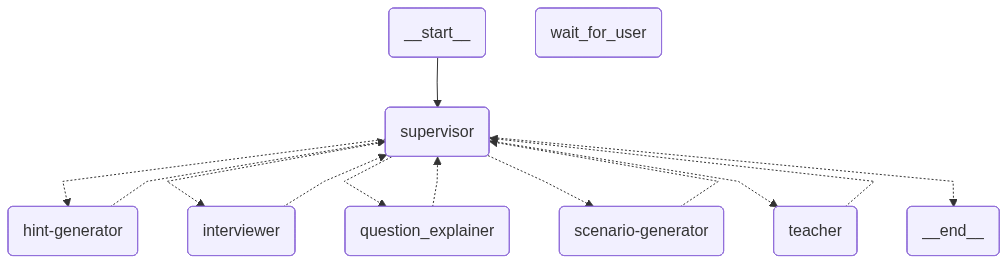

In [124]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [125]:
import pprint
import uuid
config = {
    "configurable": {
        "thread_id": uuid.uuid4()
    }
}

inputs = {
    "messages": [
        HumanMessage(
            content="topic: Load Balancer, Difficulty: hard"
        )
    ]
}

for event in app.stream(inputs, config=config):
    for key, value in event.items():
        if value is None:
            continue
        last_message = value.get("messages", [])[-1] if "messages" in value else None
        if last_message:
            pprint.pprint(f"Output from node '{key}':")
            pprint.pprint(last_message, indent=2, width=80, depth=None)
            print()

--- Workflow Transition: Supervisor → SCENARIO-GENERATOR ---
"Output from node 'supervisor':"
AIMessage(content='The user has defined the topic and difficulty level, so the scenario-generator is required to formulate an appropriate interview scenario based on these parameters.', additional_kwargs={}, response_metadata={}, name='supervisor', id='867fa1de-2b7f-46b3-9c94-158c2b41c89e', tool_calls=[], invalid_tool_calls=[])

--- Workflow Transition: Scenario Generator → Supervisor (Query Enhanced) ---
Enhanced Query: [{'type': 'text', 'text': '\n\n**Refined Specification:**\n\n*   **Topic:** Distributed System Design: Load Balancer Implementation and Orchestration\n*   **Difficulty Level:** Hard (Architectural and Systems Engineering focus)\n*   **Required Depth:**\n    *   **Architectural Design:** Must go beyond simple round-robin algorithms. The scenario should cover Layer 4 (Transport) vs. Layer 7 (Application) load balancing, consistent hashing for stateful services, and global server

In [126]:
response2 =  """well i understand sticky session now, is this right?Session persistence (also called sticky sessions) ensures that a user's requests are consistently routed to the same backend server throughout their session. This is especially important during a shopping cart checkout because if session data, such as the cart contents or authentication state, is stored only in the server's local memory, sending subsequent requests to a different server could result in the user losing their cart or being logged out.
By enabling session persistence, the load balancer ensures that all requests from that user continue to reach the same backend server, providing a seamless experience during checkout.
However, there are trade-offs. First, it can lead to uneven load distribution because some servers may end up handling more long-lived sessions than others. Second, if the server handling a sticky session fails, the user may lose their session unless the session data is replicated or stored externally. Third, it reduces flexibility in routing traffic because the load balancer is constrained to send requests to a specific server instead of the least-loaded healthy server.
In modern architectures, instead of relying heavily on sticky sessions, it's generally preferable to build stateless application servers. Session data can be stored in a shared external store such as Redis or a database. This allows any backend server to handle any request, improving scalability, fault tolerance, and load balancing efficiency while still preserving the user's session if a server fails."""

response1 = """A load balancer is necessary because a single server becomes a bottleneck as traffic increases. If that server crashes or becomes overloaded, the entire website becomes unavailable. By placing a load balancer in front of multiple backend servers, incoming requests can be distributed evenly, improving both scalability and availability.
For traffic distribution, I would use the Round Robin algorithm because it's simple and works well when all backend servers have similar capacity. If some servers are more powerful, a Weighted Round Robin approach would be better.

The load balancer should also perform periodic health checks on backend servers. If a server fails to respond to these health checks, it is marked as unhealthy and no new requests are forwarded to it until it recovers.
Regarding Layer 4 and Layer 7 routing, Layer 4 operates at the transport layer and forwards traffic based on IP addresses and TCP/UDP ports, making it very fast. Layer 7 operates at the application layer and can inspect HTTP requests, allowing routing based on URL paths, headers, or cookies. For an e-commerce application, Layer 7 would be more suitable because it enables routing requests like /checkout or /images to different backend services while also supporting features such as SSL termination and session persistence."""

response3= """ 
In a distributed system, observability is critical because a transaction can fail at multiple layers—application, network, database, or infrastructure. I would use a combination of metrics, distributed tracing, structured logging, and alerting to identify where the bottleneck occurs.

First, I would implement distributed tracing using tools like OpenTelemetry with a backend such as Jaeger or Zipkin. Every request would carry a unique Trace ID, allowing me to follow the transaction as it moves through the API gateway, application servers, Redis, message queues, and multiple database shards.

For metrics, I would monitor:

Transaction latency (average and P95/P99)
Cross-shard transaction duration
Number of failed or rolled-back transactions
2PC prepare and commit times
Database query latency
Lock wait time and deadlock count
Network latency and packet loss between services
CPU, memory, disk I/O, and connection pool utilization for each database node

To distinguish between network issues and database lock contention, I would compare both infrastructure and database metrics.

If it is a network issue, I would expect to see:

Increased network latency between services
Packet loss or connection timeouts
Higher RPC or API response times across multiple services
Retries or failed connections in application logs

If it is database lock contention, I would instead expect:

Increased lock wait times
Blocking queries
Deadlocks
Long-running transactions
High query execution time while network latency remains normal

Distributed tracing would also help identify where the delay occurs. For example, if a trace shows most of the transaction time is spent waiting on a database span, the bottleneck is likely the database. If the delay appears between service calls before reaching the database, it points toward a network or communication problem.

Finally, I would create dashboards and alerts using Prometheus and Grafana to monitor key metrics such as transaction latency, error rates, lock wait times, and network latency. Alerts would trigger when thresholds are exceeded so the operations team can investigate before users are significantly impacted.

In summary, I would combine metrics to detect anomalies, distributed tracing to locate where the latency occurs, and structured logs to understand why it occurred. Together, these provide a complete picture of the health of a distributed transaction.

"""


for event in app.stream(
    Command(
        resume=response1),
    config=config,
):
    print(event)

{'wait_for_user': {'messages': [HumanMessage(content="A load balancer is necessary because a single server becomes a bottleneck as traffic increases. If that server crashes or becomes overloaded, the entire website becomes unavailable. By placing a load balancer in front of multiple backend servers, incoming requests can be distributed evenly, improving both scalability and availability.\nFor traffic distribution, I would use the Round Robin algorithm because it's simple and works well when all backend servers have similar capacity. If some servers are more powerful, a Weighted Round Robin approach would be better.\n\nThe load balancer should also perform periodic health checks on backend servers. If a server fails to respond to these health checks, it is marked as unhealthy and no new requests are forwarded to it until it recovers.\nRegarding Layer 4 and Layer 7 routing, Layer 4 operates at the transport layer and forwards traffic based on IP addresses and TCP/UDP ports, making it ver

In [127]:
response = app.invoke(
    {
        "messages": [
            HumanMessage(content="summarise the chat")
        ]
    },
    config=config,
)

print(response)

--- Workflow Transition: Supervisor → INTERVIEWER ---
=============pending_topics:  ['Consistent Hashing for Session Affinity', 'Global Server Load Balancing (GSLB) Strategies', 'Thundering Herd Mitigation', 'Connection Draining and Graceful Shutdown', 'Kernel Bypass (DPDK/XDP) for High Throughput', 'Circuit Breaking Patterns', 'Distributed Rate Limiting', 'Active-Active Multi-Region Orchestration', 'TLS Termination Strategies', 'Service Mesh Integration (Envoy/Istio)']
evaluation:  overall_assessment='The candidate failed to engage with the technical depth of the question, providing a non-responsive answer that ignored the specific constraints regarding kernel-bypass and stateful connection handling.' strengths=['Understands basic load balancing definitions', 'Correctly identifies the difference between Layer 4 and Layer 7 routing'] weaknesses=['Failed to address the specific scale (5 million RPS)', 'Ignored global distribution and regional failover requirements', 'Did not discuss hig

In [128]:
state = app.get_state(config)

print(state.values)

{'messages': [HumanMessage(content='topic: Load Balancer, Difficulty: hard', additional_kwargs={}, response_metadata={}, id='30c368fa-7e43-4649-b078-600fbea3f1a2'), AIMessage(content='The user has defined the topic and difficulty level, so the scenario-generator is required to formulate an appropriate interview scenario based on these parameters.', additional_kwargs={}, response_metadata={}, name='supervisor', id='867fa1de-2b7f-46b3-9c94-158c2b41c89e', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='{\n  "title": "Global Edge Load Balancer Architecture for High-Frequency Trading",\n  "description": "Design a globally distributed Layer 7 load balancing tier capable of handling 5 million requests per second with sub-10ms latency. The system must route traffic across three disparate geographical regions while maintaining session affinity for stateful websocket connections. You must account for dynamic circuit breaking when backend services report high tail-latency, and provide a

In [129]:
from pprint import pprint
pprint(state)

StateSnapshot(values={'messages': [HumanMessage(content='topic: Load Balancer, Difficulty: hard', additional_kwargs={}, response_metadata={}, id='30c368fa-7e43-4649-b078-600fbea3f1a2'), AIMessage(content='The user has defined the topic and difficulty level, so the scenario-generator is required to formulate an appropriate interview scenario based on these parameters.', additional_kwargs={}, response_metadata={}, name='supervisor', id='867fa1de-2b7f-46b3-9c94-158c2b41c89e', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='{\n  "title": "Global Edge Load Balancer Architecture for High-Frequency Trading",\n  "description": "Design a globally distributed Layer 7 load balancing tier capable of handling 5 million requests per second with sub-10ms latency. The system must route traffic across three disparate geographical regions while maintaining session affinity for stateful websocket connections. You must account for dynamic circuit breaking when backend services report high tail-l